Setup & Config

In [1]:
import os, shutil, hashlib, zipfile
from collections import defaultdict
from PIL import Image, ImageOps, ImageFile
import numpy as np
import cv2
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = False  # we WANT truncated images to error so we can remove them

# ── Paths ──────────────────────────────────────────────────────────────
MERGED_ZIP           = '/content/drive/MyDrive/merged_dataset.zip'                 # ✏️ path to your uploaded zip
MERGED_PATH          = '/content/merged_extracted'
CLEANED_PATH         = '/content/cleaned_dataset'
REVIEW_PATH          = '/content/review_flagged'             # blur, aspect ratio, low-coverage
EXPOSURE_REVIEW_PATH = '/content/review_exposure'            # too dark / overexposed / low contrast
LOG_PATH             = '/content/cleaning_logs'

# ── Config ─────────────────────────────────────────────────────────────
TARGET_SIZE      = 512
TARGET_PER_CLASS = 1000
CLASSES_KEEP     = ['blast', 'bacterial_leaf_blight', 'brown_spot']  # healthy excluded

VALID_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp',
              '.JPG', '.JPEG', '.PNG', '.BMP', '.TIFF', '.WEBP')

# ── Extract zip ────────────────────────────────────────────────────────
if not os.path.exists(MERGED_PATH):
    print(f"📦 Extracting {MERGED_ZIP} ...")
    os.makedirs(MERGED_PATH, exist_ok=True)
    with zipfile.ZipFile(MERGED_ZIP, 'r') as z:
        z.extractall(MERGED_PATH)
    print(f"✅ Extracted to {MERGED_PATH}")
else:
    print(f"⏭️  Already extracted — skipping.")

for p in [CLEANED_PATH, REVIEW_PATH, EXPOSURE_REVIEW_PATH, LOG_PATH]:
    os.makedirs(p, exist_ok=True)

# ── Collect images (only target classes) ───────────────────────────────
def get_all_images(root_path, keep_classes=None):
    entries = []
    for dirpath, _, filenames in os.walk(root_path):
        cls = os.path.basename(dirpath)
        if keep_classes and cls not in keep_classes:
            continue
        for fname in filenames:
            if fname.lower().endswith(VALID_EXTS):
                entries.append((cls, fname, os.path.join(dirpath, fname)))
    return entries

entries = get_all_images(MERGED_PATH, keep_classes=CLASSES_KEEP)
print(f"\n📁 Found {len(entries)} images across target classes")

if len(entries) == 0:
    print("⚠️  No images found. Folder structure:")
    for root, dirs, _ in os.walk(MERGED_PATH):
        depth = root.replace(MERGED_PATH, '').count(os.sep)
        if depth < 3:
            print(f"  {'  '*depth}{os.path.basename(root)}/")
    raise SystemExit("Fix MERGED_PATH then re-run this block.")

# ── Master tracking dataframe ──────────────────────────────────────────
master = pd.DataFrame(
    [{'class': c, 'file': f, 'path': p, 'status': 'pending', 'reason': ''}
     for c, f, p in entries]
)

print(f"\n  Class counts (raw input):")
for cls, cnt in master['class'].value_counts().items():
    status = '✅' if cnt >= TARGET_PER_CLASS else '⚠️ '
    print(f"    {status} {cls:<30} {cnt}")
print(f"\n✅ Tracking {len(master)} images. Target: ≥{TARGET_PER_CLASS} clean per class.")

📦 Extracting /content/drive/MyDrive/merged_dataset.zip ...
✅ Extracted to /content/merged_extracted

📁 Found 15587 images across target classes

  Class counts (raw input):
    ✅ brown_spot                     5738
    ✅ bacterial_leaf_blight          5001
    ✅ blast                          4848

✅ Tracking 15587 images. Target: ≥1000 clean per class.


Step A1: Corrupt & Incomplete Image Removal
Hard remove. PIL verify() catches header corruption; load() catches truncated files.

In [2]:
print("=" * 60)
print("  STEP A1 — Corrupt & Incomplete Image Removal")
print("=" * 60)

def check_integrity(fpath):
    try:
        with Image.open(fpath) as img:
            img.verify()
        with Image.open(fpath) as img:
            img.load()
        return True, None
    except Exception as e:
        return False, str(e)[:80]

corrupt_count = 0
for idx, row in tqdm(master.iterrows(), total=len(master), desc="Integrity check"):
    if row['status'] != 'pending':
        continue
    ok, err = check_integrity(row['path'])
    if not ok:
        master.at[idx, 'status'] = 'removed'
        master.at[idx, 'reason'] = f'corrupt: {err}'
        corrupt_count += 1

print(f"\n  ❌ Corrupt / incomplete removed : {corrupt_count}")
print(f"  ✅ Remaining                    : {(master['status']=='pending').sum()}")

  STEP A1 — Corrupt & Incomplete Image Removal


Integrity check: 100%|██████████| 15587/15587 [03:40<00:00, 70.85it/s]


  ❌ Corrupt / incomplete removed : 0
  ✅ Remaining                    : 15587


Step A2: Exact & Near-Duplicate Removal
Hard remove. MD5 = byte-identical. pHash (Hamming ≤ 5) = resized/recompressed copies, checked per-class only.

In [3]:
!pip install -q imagehash
import imagehash

print("=" * 60)
print("  STEP A2 — Exact & Near-Duplicate Removal")
print("=" * 60)

PHASH_THRESHOLD = 5

# ── MD5 exact duplicates ───────────────────────────────────────────────
md5_map = defaultdict(list)
pending_mask = master['status'] == 'pending'

for idx, row in tqdm(master[pending_mask].iterrows(), total=pending_mask.sum(), desc="MD5 hashing"):
    try:
        with open(row['path'], 'rb') as f:
            md5_map[hashlib.md5(f.read()).hexdigest()].append(idx)
    except Exception:
        pass

md5_dup = 0
for idx_list in md5_map.values():
    for idx in idx_list[1:]:
        master.at[idx, 'status'] = 'removed'
        master.at[idx, 'reason'] = 'exact_duplicate_md5'
        md5_dup += 1

print(f"\n  ❌ Exact duplicates (MD5)       : {md5_dup}")

# ── pHash near-duplicates (per-class) ─────────────────────────────────
pending_mask = master['status'] == 'pending'
phash_map = {}

for idx, row in tqdm(master[pending_mask].iterrows(), total=pending_mask.sum(), desc="pHash hashing"):
    try:
        with Image.open(row['path']) as img:
            phash_map[idx] = imagehash.phash(img.convert('RGB'))
    except Exception:
        pass

phash_dup = 0
for cls in CLASSES_KEEP:
    cls_indices = [i for i in phash_map if master.at[i, 'class'] == cls]
    seen = []
    for idx in cls_indices:
        is_dup = any(phash_map[idx] - phash_map[s] <= PHASH_THRESHOLD for s in seen)
        if is_dup:
            master.at[idx, 'status'] = 'removed'
            master.at[idx, 'reason'] = f'near_duplicate_phash (dist<={PHASH_THRESHOLD})'
            phash_dup += 1
        else:
            seen.append(idx)

print(f"  ❌ Near-duplicates (pHash ≤{PHASH_THRESHOLD})   : {phash_dup}")
print(f"  ✅ Remaining                    : {(master['status']=='pending').sum()}")

print(f"\n  Post-dedup class counts:")
for cls, cnt in master[master['status']=='pending']['class'].value_counts().items():
    gap = max(0, TARGET_PER_CLASS - cnt)
    note = f"  ← needs +{gap} after cleaning" if gap > 0 else ""
    print(f"    {cls:<30} {cnt}{note}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.9 MB/s eta 0:00:00
  STEP A2 — Exact & Near-Duplicate Removal


MD5 hashing: 100%|██████████| 15587/15587 [00:24<00:00, 640.90it/s]



  ❌ Exact duplicates (MD5)       : 1633


pHash hashing: 100%|██████████| 13954/13954 [07:05<00:00, 32.78it/s]


  ❌ Near-duplicates (pHash ≤5)   : 3104
  ✅ Remaining                    : 10850

  Post-dedup class counts:
    blast                          3772
    brown_spot                     3750
    bacterial_leaf_blight          3328


Step A3: Blur Detection
Soft flag → review folder. Histogram shown first so you can tune the threshold before anything gets flagged.

  STEP A3 — Blur Detection (Laplacian Variance)

  Pending images to score: 10850


Blur scoring: 100%|██████████| 10850/10850 [04:53<00:00, 36.95it/s]


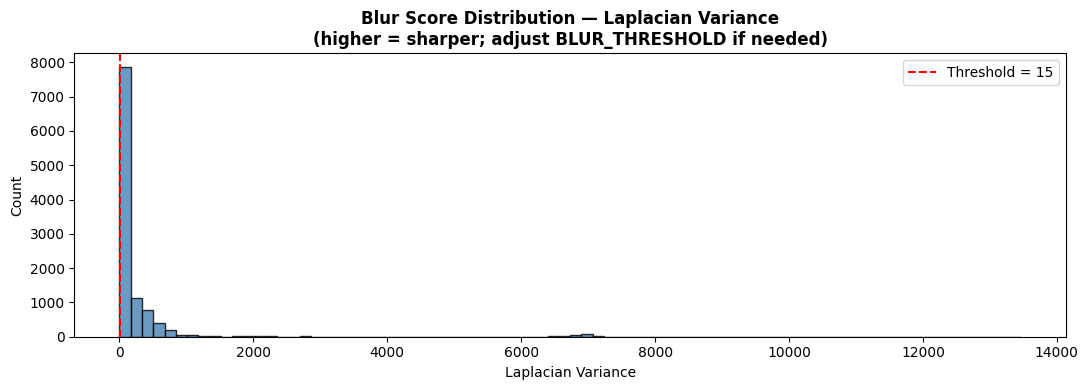


  Score stats: min=1  median=55  mean=313  max=13462

  Percentile breakdown:
    1th percentile: 1.6
    2th percentile: 2.0
    5th percentile: 3.1
    10th percentile: 4.8
    15th percentile: 6.7
    20th percentile: 8.6
    25th percentile: 11.1
    50th percentile: 55.5

  Images below threshold 15: 3215 will be flagged

  ✏️  If that number looks too high/low, update BLUR_THRESHOLD and re-run.


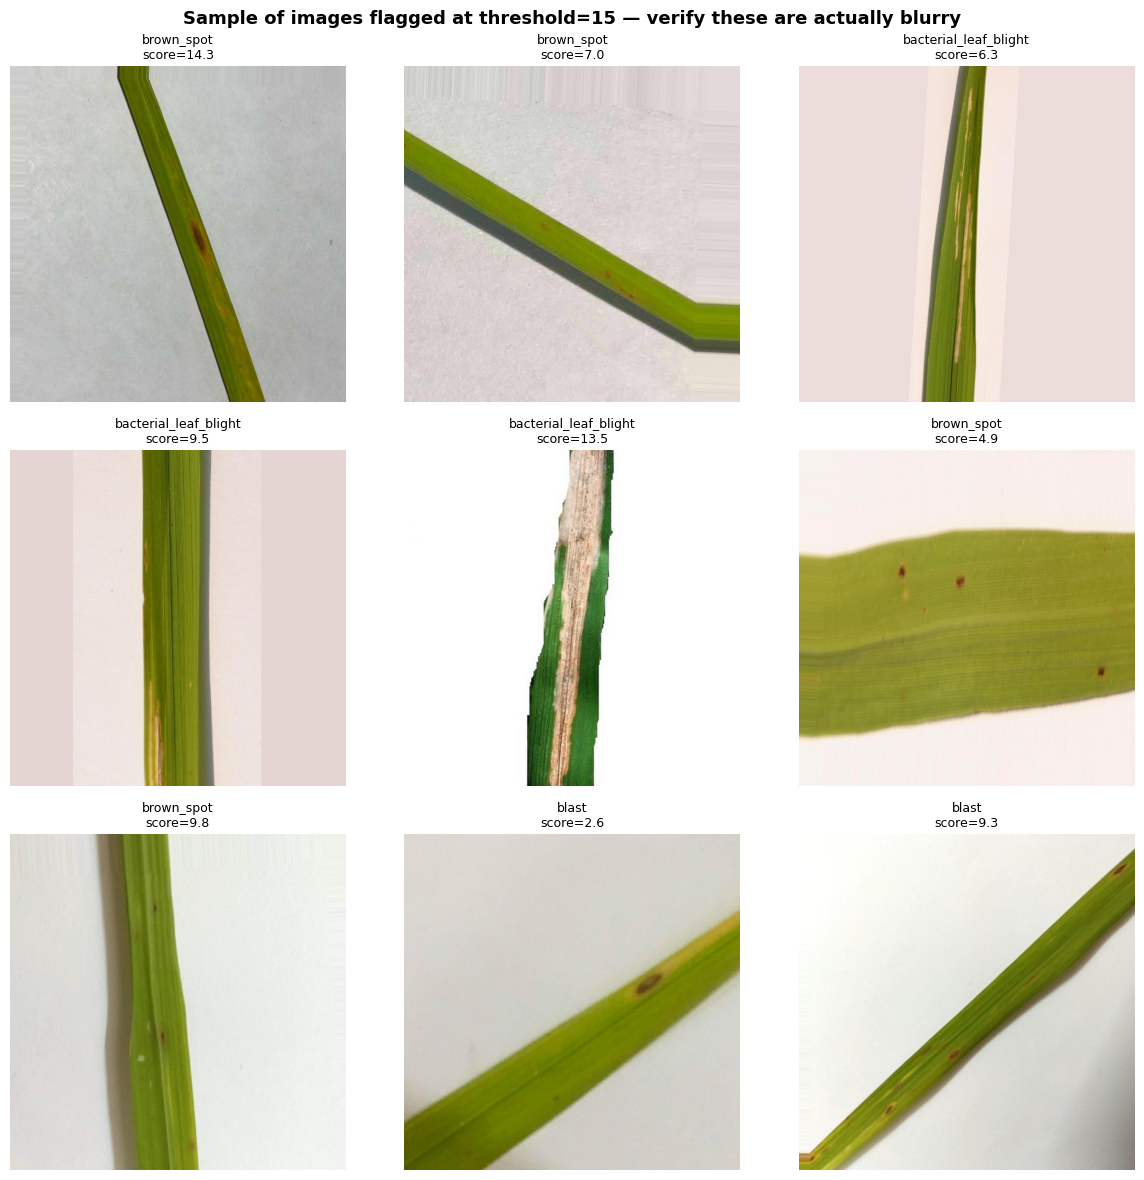


  ⚠️  Inspect the grid above. If these look genuinely blurry/unusable,
      proceed. If they look fine, lower BLUR_THRESHOLD further and re-run.

  🚩 Flagged as blurry (soft flag, for manual review): 3215
  ✅ Still pending                                     : 7635


In [4]:
print("=" * 60)
print("  STEP A3 — Blur Detection (Laplacian Variance)")
print("=" * 60)

BLUR_THRESHOLD = 50   # ✏️ tune after seeing histogram AND visual sample check below; lower = less strict

def laplacian_var(fpath):
    img = cv2.imread(fpath)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

pending_mask = master['status'] == 'pending'
print(f"\n  Pending images to score: {pending_mask.sum()}")

if pending_mask.sum() == 0:
    raise RuntimeError(
        "No pending images in `master` — nothing to score. "
        "Check that `master` was built/rebuilt correctly and earlier steps "
        "(corrupt check, MD5/pHash dedup) left some rows as 'pending'."
    )

blur_scores = {}
for idx, row in tqdm(master[pending_mask].iterrows(), total=pending_mask.sum(), desc="Blur scoring"):
    blur_scores[idx] = laplacian_var(row['path'])

master['blur_score'] = master.index.map(lambda i: blur_scores.get(i))

# ── Histogram — look before flagging ──────────────────────────────────
valid_scores = [s for s in blur_scores.values() if s is not None]

if len(valid_scores) == 0:
    raise RuntimeError(
        "All blur scores came back None — cv2.imread() failed for every image. "
        "This usually means the file paths in `master['path']` don't resolve "
        "(e.g. runtime reset, dataset re-extracted to a different location). "
        "Re-run the dataset rebuild/extraction step before this block."
    )

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(valid_scores, bins=80, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(BLUR_THRESHOLD, color='red', linewidth=1.5, linestyle='--',
           label=f'Threshold = {BLUR_THRESHOLD}')
ax.set_title('Blur Score Distribution — Laplacian Variance\n(higher = sharper; adjust BLUR_THRESHOLD if needed)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Laplacian Variance')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n  Score stats: min={min(valid_scores):.0f}  "
      f"median={np.median(valid_scores):.0f}  "
      f"mean={np.mean(valid_scores):.0f}  "
      f"max={max(valid_scores):.0f}")

print(f"\n  Percentile breakdown:")
for p in [1, 2, 5, 10, 15, 20, 25, 50]:
    print(f"    {p}th percentile: {np.percentile(valid_scores, p):.1f}")

print(f"\n  Images below threshold {BLUR_THRESHOLD}: "
      f"{sum(1 for s in valid_scores if s < BLUR_THRESHOLD)} will be flagged")
print(f"\n  ✏️  If that number looks too high/low, update BLUR_THRESHOLD and re-run.")

# ── Visual sanity check — look at lowest-scoring images BEFORE trusting the threshold ──
import random

low_score_indices = [idx for idx, s in blur_scores.items() if s is not None and s < BLUR_THRESHOLD]

if low_score_indices:
    sample = random.sample(low_score_indices, min(9, len(low_score_indices)))
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for ax, idx in zip(axes.flat, sample):
        row = master.loc[idx]
        try:
            img = Image.open(row['path'])
            ax.imshow(img)
            ax.set_title(f"{row['class']}\nscore={blur_scores[idx]:.1f}", fontsize=9)
        except Exception:
            pass
        ax.axis('off')
    for ax in axes.flat[len(sample):]:
        ax.axis('off')
    plt.suptitle(f'Sample of images flagged at threshold={BLUR_THRESHOLD} — verify these are actually blurry',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"\n  ⚠️  Inspect the grid above. If these look genuinely blurry/unusable,")
    print(f"      proceed. If they look fine, lower BLUR_THRESHOLD further and re-run.")
else:
    print(f"\n  No images below threshold {BLUR_THRESHOLD} to preview.")

# ── Apply flag (soft flag — moves to 'flagged' for review, does NOT delete) ──
pending_mask = master['status'] == 'pending'   # recompute — don't trust the stale one from earlier
blur_flag = 0
for idx, row in master[pending_mask].iterrows():
    score = blur_scores.get(idx)
    if score is not None and score < BLUR_THRESHOLD:
        master.at[idx, 'status'] = 'flagged'
        master.at[idx, 'reason'] = f'blur (laplacian={score:.1f} < {BLUR_THRESHOLD})'
        blur_flag += 1

print(f"\n  🚩 Flagged as blurry (soft flag, for manual review): {blur_flag}")
print(f"  ✅ Still pending                                     : {(master['status']=='pending').sum()}")

Step A4: Brightness & Contrast Outliers
Soft flag → separate review_exposure/ folder. Histograms shown first.

  STEP A4 — Brightness & Contrast Outlier Detection


Exposure check: 100%|██████████| 7635/7635 [03:02<00:00, 41.81it/s]


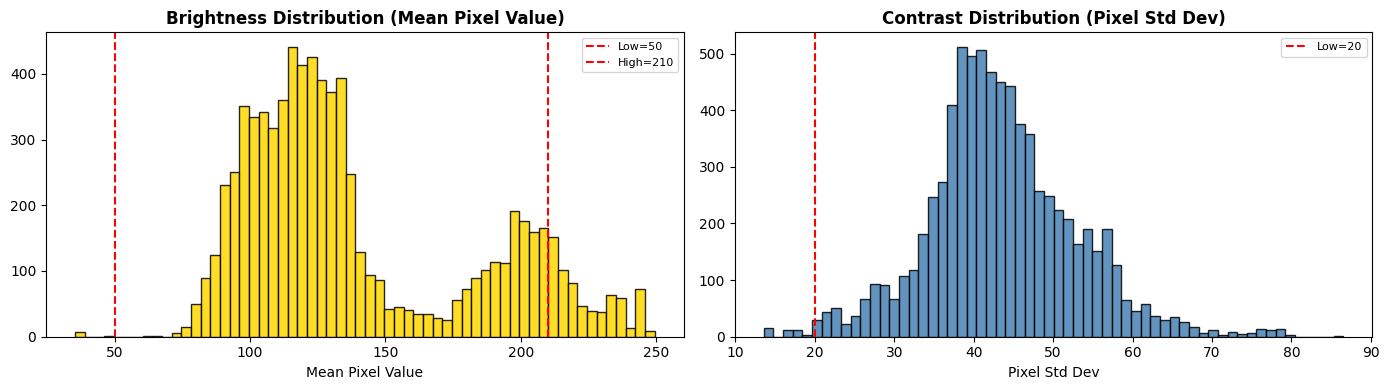

  Brightness: median=125.0  mean=139.2
  Contrast  : median=42.7  mean=43.4

  🚩 Flagged for exposure issues  : 751
  ✅ Still pending               : 6884


In [5]:
print("=" * 60)
print("  STEP A4 — Brightness & Contrast Outlier Detection")
print("=" * 60)

BRIGHTNESS_LOW  = 50    # ✏️ below = too dark
BRIGHTNESS_HIGH = 210   # ✏️ above = overexposed / washed out
CONTRAST_LOW    = 20    # ✏️ below = flat image; hurts lesion extraction

def exposure_stats(fpath):
    img = cv2.imread(fpath)
    if img is None:
        return None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return float(gray.mean()), float(gray.std())

pending_mask  = master['status'] == 'pending'
exposure_data = {}

for idx, row in tqdm(master[pending_mask].iterrows(), total=pending_mask.sum(), desc="Exposure check"):
    exposure_data[idx] = exposure_stats(row['path'])

master['brightness'] = master.index.map(lambda i: exposure_data.get(i, (None, None))[0])
master['contrast']   = master.index.map(lambda i: exposure_data.get(i, (None, None))[1])

valid_b = [v[0] for v in exposure_data.values() if v[0] is not None]
valid_c = [v[1] for v in exposure_data.values() if v[1] is not None]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(valid_b, bins=60, color='gold', edgecolor='black', alpha=0.85)
axes[0].axvline(BRIGHTNESS_LOW,  color='red', linestyle='--', label=f'Low={BRIGHTNESS_LOW}')
axes[0].axvline(BRIGHTNESS_HIGH, color='red', linestyle='--', label=f'High={BRIGHTNESS_HIGH}')
axes[0].set_title('Brightness Distribution (Mean Pixel Value)', fontweight='bold')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].legend(fontsize=8)

axes[1].hist(valid_c, bins=60, color='steelblue', edgecolor='black', alpha=0.85)
axes[1].axvline(CONTRAST_LOW, color='red', linestyle='--', label=f'Low={CONTRAST_LOW}')
axes[1].set_title('Contrast Distribution (Pixel Std Dev)', fontweight='bold')
axes[1].set_xlabel('Pixel Std Dev')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"  Brightness: median={np.median(valid_b):.1f}  mean={np.mean(valid_b):.1f}")
print(f"  Contrast  : median={np.median(valid_c):.1f}  mean={np.mean(valid_c):.1f}")

exposure_flag = 0
for idx, row in master[pending_mask].iterrows():
    b, c = exposure_data.get(idx, (None, None))
    if b is None:
        continue
    if b < BRIGHTNESS_LOW:
        master.at[idx, 'status'] = 'flagged'
        master.at[idx, 'reason'] = f'too_dark (brightness={b:.1f})'
        exposure_flag += 1
    elif b > BRIGHTNESS_HIGH:
        master.at[idx, 'status'] = 'flagged'
        master.at[idx, 'reason'] = f'overexposed (brightness={b:.1f})'
        exposure_flag += 1
    elif c < CONTRAST_LOW:
        master.at[idx, 'status'] = 'flagged'
        master.at[idx, 'reason'] = f'low_contrast (contrast={c:.1f})'
        exposure_flag += 1

print(f"\n  🚩 Flagged for exposure issues  : {exposure_flag}")
print(f"  ✅ Still pending               : {(master['status']=='pending').sum()}")

Step A5: Low Leaf Coverage & Whole-Field Detection
Soft flag → review folder. HSV green-mask heuristic.

In [6]:
print("=" * 60)
print("  STEP A5 — Low Leaf Coverage & Whole-Field Detection")
print("=" * 60)

LOW_COVERAGE_THRESHOLD = 0.10   # ✏️ < 10% leaf-coloured pixels → flag
MANY_BLOBS_THRESHOLD   = 15     # ✏️ many disconnected blobs → likely field shot

def leaf_coverage(fpath):
    img = cv2.imread(fpath)
    if img is None:
        return None, None
    img  = cv2.resize(img, (256, 256))
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([25, 30, 30]), np.array([95, 255, 255]))
    coverage    = mask.sum() / 255 / (256 * 256)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return float(coverage), len(contours)

pending_mask  = master['status'] == 'pending'
coverage_data = {}

for idx, row in tqdm(master[pending_mask].iterrows(), total=pending_mask.sum(), desc="Coverage check"):
    coverage_data[idx] = leaf_coverage(row['path'])

coverage_flag = 0
for idx, row in master[pending_mask].iterrows():
    cov, blobs = coverage_data.get(idx, (None, None))
    if cov is None:
        continue
    if cov < LOW_COVERAGE_THRESHOLD:
        master.at[idx, 'status'] = 'flagged'
        master.at[idx, 'reason'] = f'low_leaf_coverage ({cov:.2%})'
        coverage_flag += 1
    elif blobs > MANY_BLOBS_THRESHOLD:
        master.at[idx, 'status'] = 'flagged'
        master.at[idx, 'reason'] = f'possible_whole_field ({blobs} blobs)'
        coverage_flag += 1

print(f"  🚩 Flagged for low coverage / field shots : {coverage_flag}")
print(f"  ✅ Still pending                         : {(master['status']=='pending').sum()}")
print(f"\n  ⚠️  Heuristic only — false positives expected. Review before discarding.")

  STEP A5 — Low Leaf Coverage & Whole-Field Detection


Coverage check: 100%|██████████| 6884/6884 [01:27<00:00, 78.56it/s]


  🚩 Flagged for low coverage / field shots : 2258
  ✅ Still pending                         : 4626

  ⚠️  Heuristic only — false positives expected. Review before discarding.


Step A6: Extreme Aspect Ratio Flagging
Soft flag → review folder. Outside 0.5–2.0 would distort badly under letterbox padding.

  STEP A6 — Extreme Aspect Ratio Check


Aspect ratio: 100%|██████████| 4626/4626 [00:00<00:00, 5325.61it/s]


  🚩 Flagged for extreme aspect ratio : 36
  ✅ Still pending                   : 4590


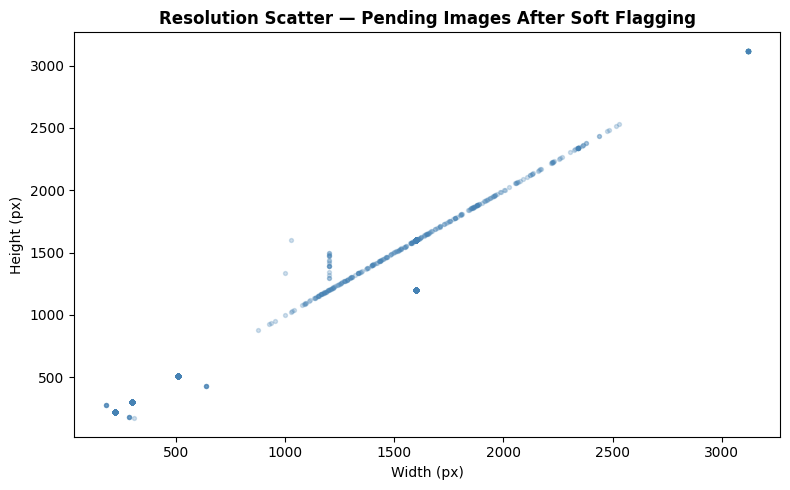

In [7]:
print("=" * 60)
print("  STEP A6 — Extreme Aspect Ratio Check")
print("=" * 60)

ASPECT_LOW  = 0.5
ASPECT_HIGH = 2.0

pending_mask = master['status'] == 'pending'
res_data     = {}

for idx, row in tqdm(master[pending_mask].iterrows(), total=pending_mask.sum(), desc="Aspect ratio"):
    try:
        with Image.open(row['path']) as img:
            w, h = img.size
            res_data[idx] = (w, h, round(w / h, 3))
    except Exception:
        pass

master['width']        = master.index.map(lambda i: res_data.get(i, (None,)*3)[0])
master['height']       = master.index.map(lambda i: res_data.get(i, (None,)*3)[1])
master['aspect_ratio'] = master.index.map(lambda i: res_data.get(i, (None,)*3)[2])

aspect_flag = 0
for idx in res_data:
    if master.at[idx, 'status'] != 'pending':
        continue
    _, _, ar = res_data[idx]
    if ar < ASPECT_LOW or ar > ASPECT_HIGH:
        master.at[idx, 'status'] = 'flagged'
        master.at[idx, 'reason'] = f'extreme_aspect_ratio ({ar})'
        aspect_flag += 1

print(f"  🚩 Flagged for extreme aspect ratio : {aspect_flag}")
print(f"  ✅ Still pending                   : {(master['status']=='pending').sum()}")

clean_res = master[master['status'] == 'pending']
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(clean_res['width'], clean_res['height'], alpha=0.25, s=8, color='steelblue')
ax.set_title('Resolution Scatter — Pending Images After Soft Flagging', fontweight='bold')
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
plt.tight_layout()
plt.show()

Pre-Copy Class Count Check
Verify ≥ 1200 per class before writing anything to disk.

In [8]:
print("=" * 60)
print("  PRE-COPY CHECK — Will we hit ≥1200 per class?")
print("=" * 60)

pending_counts = master[master['status'] == 'pending']['class'].value_counts()
flagged_counts = master[master['status'] == 'flagged']['class'].value_counts()
removed_counts = master[master['status'] == 'removed']['class'].value_counts()

print(f"\n  {'Class':<30} {'Pending':>8} {'Flagged':>8} {'Removed':>8}  {'OK?':>6}")
print(f"  {'-'*30} {'-'*8} {'-'*8} {'-'*8}  {'-'*6}")
all_ok = True
for cls in CLASSES_KEEP:
    p  = pending_counts.get(cls, 0)
    f  = flagged_counts.get(cls, 0)
    r  = removed_counts.get(cls, 0)
    ok = '✅' if p >= TARGET_PER_CLASS else '❌'
    if p < TARGET_PER_CLASS:
        all_ok = False
    print(f"  {cls:<30} {p:>8} {f:>8} {r:>8}  {ok:>6}")

print()
if all_ok:
    print(f"  ✅ All classes will meet the ≥{TARGET_PER_CLASS} target. Proceed to Block 9.")
else:
    print(f"  ❌ One or more classes will fall short of {TARGET_PER_CLASS}.")
    print(f"     → Raise thresholds in Blocks 4–7 (less aggressive), then re-run.")
    print(f"     → Or manually rescue some flagged images post-review.")

  PRE-COPY CHECK — Will we hit ≥1200 per class?

  Class                           Pending  Flagged  Removed     OK?
  ------------------------------ -------- -------- --------  ------
  blast                              1683     2089     1076       ✅
  bacterial_leaf_blight              1211     2117     1673       ✅
  brown_spot                         1696     2054     1988       ✅

  ✅ All classes will meet the ≥1000 target. Proceed to Block 9.


Copy Flagged Images to Review Folders

In [9]:
print("=" * 60)
print("  Copying Flagged Images to Review Folders")
print("=" * 60)

EXPOSURE_TAGS = ('too_dark', 'overexposed', 'low_contrast')

flagged_df = master[master['status'] == 'flagged']
exp_count  = 0
gen_count  = 0

for idx, row in tqdm(flagged_df.iterrows(), total=len(flagged_df), desc="Copying flagged"):
    tag         = row['reason'].split(' ')[0].rstrip(':').rstrip('(')
    is_exposure = tag in EXPOSURE_TAGS
    dest_root   = EXPOSURE_REVIEW_PATH if is_exposure else REVIEW_PATH
    dest_dir    = os.path.join(dest_root, tag, row['class'])
    os.makedirs(dest_dir, exist_ok=True)
    dest_file = os.path.join(dest_dir, row['file'])
    if not os.path.exists(dest_file):
        shutil.copy2(row['path'], dest_file)
    if is_exposure:
        exp_count += 1
    else:
        gen_count += 1

print(f"\n  📁 General review  ({REVIEW_PATH}):")
print(f"     {gen_count} images — blur / aspect ratio / low coverage")
print(f"\n  📁 Exposure review ({EXPOSURE_REVIEW_PATH}):")
print(f"     {exp_count} images — too dark / overexposed / low contrast")

print(f"\n  Breakdown by reason:")
reason_summary = (
    flagged_df['reason']
    .apply(lambda r: r.split(' ')[0].rstrip(':').rstrip('('))
    .value_counts()
)
for reason, count in reason_summary.items():
    folder = 'exposure' if reason in EXPOSURE_TAGS else 'review'
    print(f"    {reason:<35} {count:>5}  → {folder}/")

  Copying Flagged Images to Review Folders


Copying flagged: 100%|██████████| 6260/6260 [00:19<00:00, 321.39it/s]


  📁 General review  (/content/review_flagged):
     5509 images — blur / aspect ratio / low coverage

  📁 Exposure review (/content/review_exposure):
     751 images — too dark / overexposed / low contrast

  Breakdown by reason:
    blur                                 3215  → review/
    possible_whole_field                 1894  → review/
    overexposed                           685  → exposure/
    low_leaf_coverage                     364  → review/
    low_contrast                           58  → exposure/
    extreme_aspect_ratio                   36  → review/
    too_dark                                8  → exposure/


Standardize & Save Clean Images

In [10]:
print("=" * 60)
print(f"  STANDARDIZE — {TARGET_SIZE}×{TARGET_SIZE} RGB letterbox")
print("=" * 60)

def standardize(fpath, target_size=TARGET_SIZE, pad=(0, 0, 0)):
    """EXIF → RGB → longest-side resize → centre-pad to square."""
    img = Image.open(fpath)
    img = ImageOps.exif_transpose(img)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    w, h   = img.size
    scale  = target_size / max(w, h)
    new_w  = int(round(w * scale))
    new_h  = int(round(h * scale))
    img    = img.resize((new_w, new_h), Image.LANCZOS)
    canvas = Image.new('RGB', (target_size, target_size), pad)
    canvas.paste(img, ((target_size - new_w) // 2,
                       (target_size - new_h) // 2))
    return canvas

pending_mask = master['status'] == 'pending'
final_df     = master[pending_mask].copy()
print(f"\n  Standardizing {len(final_df)} clean images ...")

std_ok  = 0
std_err = 0
for idx, row in tqdm(final_df.iterrows(), total=len(final_df), desc="Standardizing"):
    try:
        img      = standardize(row['path'])
        dest_dir = os.path.join(CLEANED_PATH, row['class'])
        os.makedirs(dest_dir, exist_ok=True)
        img.save(os.path.join(dest_dir, row['file']), quality=95)
        master.at[idx, 'status'] = 'cleaned'
        std_ok += 1
    except Exception as e:
        master.at[idx, 'status'] = 'error'
        master.at[idx, 'reason'] = f'standardize_failed: {str(e)[:60]}'
        std_err += 1

print(f"\n  ✅ Standardized & saved : {std_ok}")
print(f"  ❌ Errors               : {std_err}")

  STANDARDIZE — 512×512 RGB letterbox

  Standardizing 4590 clean images ...


Standardizing: 100%|██████████| 4590/4590 [02:47<00:00, 27.35it/s]


  ✅ Standardized & saved : 4590
  ❌ Errors               : 0


Final Summary & Audit Log

  PHASE A — FINAL SUMMARY

  Pipeline outcome:
    flagged        6260  (40.2%)
    removed        4737  (30.4%)
    cleaned        4590  (29.4%)

  Clean dataset — class distribution:
    ✅ blast                          1683
    ✅ bacterial_leaf_blight          1211
    ✅ brown_spot                     1696

  ✅ All classes meet the ≥1000 target!

  📄 Audit log saved : /content/cleaning_logs/phase_a_cleaning_log.csv


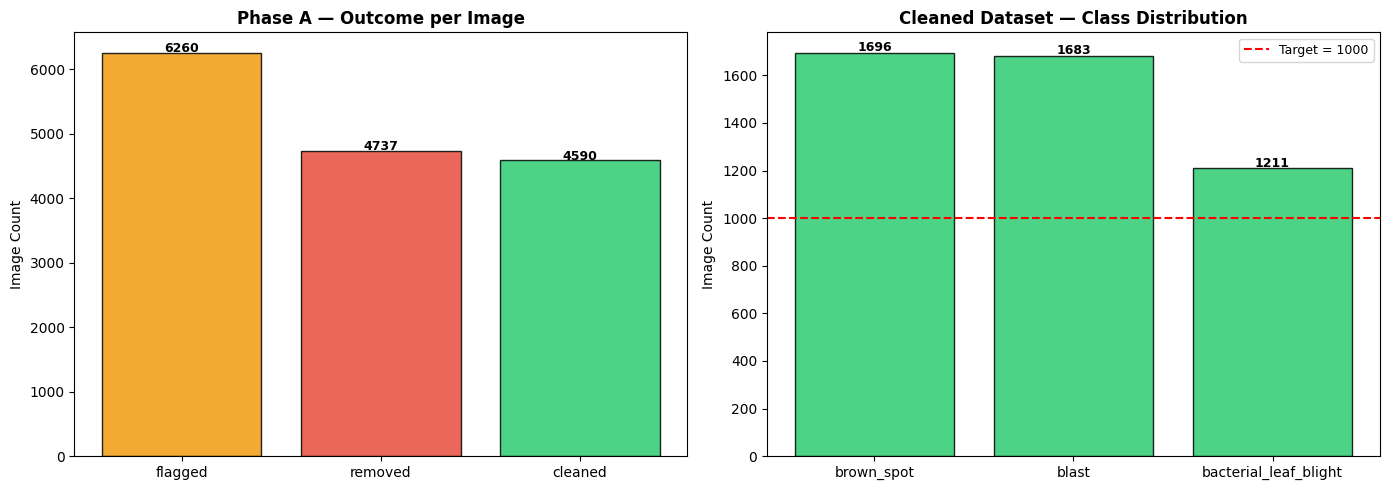


  ✅ Phase A complete!
  Review flagged → rescue false positives → proceed to Phase B


In [11]:
print("=" * 60)
print("  PHASE A — FINAL SUMMARY")
print("=" * 60)

status_counts = master['status'].value_counts()

print(f"\n  Pipeline outcome:")
for status, count in status_counts.items():
    pct = count / len(master) * 100
    print(f"    {status:<12} {count:>6}  ({pct:.1f}%)")

print(f"\n  Clean dataset — class distribution:")
cleaned_dist = master[master['status'] == 'cleaned']['class'].value_counts()
target_met   = True
for cls in CLASSES_KEEP:
    cnt  = cleaned_dist.get(cls, 0)
    flag = '✅' if cnt >= TARGET_PER_CLASS else '❌'
    if cnt < TARGET_PER_CLASS:
        target_met = False
    print(f"    {flag} {cls:<30} {cnt}")

print()
if target_met:
    print(f"  ✅ All classes meet the ≥{TARGET_PER_CLASS} target!")
else:
    print(f"  ❌ Some classes below {TARGET_PER_CLASS} — review flagged images and rescue false positives.")

log_path = os.path.join(LOG_PATH, 'phase_a_cleaning_log.csv')
master.to_csv(log_path, index=False)
print(f"\n  📄 Audit log saved : {log_path}")

colors = {'cleaned': '#2ecc71', 'flagged': '#f39c12', 'removed': '#e74c3c', 'error': '#95a5a6'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(status_counts.index, status_counts.values,
                   color=[colors.get(s, '#3498db') for s in status_counts.index],
                   edgecolor='black', alpha=0.85)
axes[0].set_title('Phase A — Outcome per Image', fontweight='bold')
axes[0].set_ylabel('Image Count')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5,
                 str(val), ha='center', fontweight='bold', fontsize=9)

bars2 = axes[1].bar(cleaned_dist.index, cleaned_dist.values,
                    color='#2ecc71', edgecolor='black', alpha=0.85)
axes[1].axhline(TARGET_PER_CLASS, color='red', linestyle='--',
                linewidth=1.5, label=f'Target = {TARGET_PER_CLASS}')
axes[1].set_title('Cleaned Dataset — Class Distribution', fontweight='bold')
axes[1].set_ylabel('Image Count')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, cleaned_dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                 str(val), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"  ✅ Phase A complete!")
print(f"  Review flagged → rescue false positives → proceed to Phase B")
print(f"{'='*60}")

Export & Download

In [12]:
import shutil
from google.colab import files

outputs = {
    'cleaned_dataset': CLEANED_PATH,
    'review_flagged':  REVIEW_PATH,
    'review_exposure': EXPOSURE_REVIEW_PATH,
}

for name, path in outputs.items():
    zip_name = f'{name}.zip'
    shutil.make_archive(name, 'zip', path)
    size_mb = os.path.getsize(zip_name) / (1024 * 1024)
    print(f"  ✅ {zip_name:<30} {size_mb:.1f} MB")

print("\nDownloading ...")
for name in outputs:
    files.download(f'{name}.zip')

  ✅ cleaned_dataset.zip            312.8 MB
  ✅ review_flagged.zip             1441.3 MB
  ✅ review_exposure.zip            596.9 MB



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>